# IMAGE DATA CRASH-COURSE

Welcome to this beginner-friendly tutorial on image preprocessing basics! This notebook will guide you through essential concepts and techniques for preparing images for machine learning tasks.

By the end, you'll understand:
- How to load and inspect images
- Color spaces and conversions  
- Resizing and scaling
- Normalization techniques
- Data augmentation
- Preparing data for ML models

Let's get started!

### Student change points

This notebook is meant to be experimented with. When you see a short list, a number, or a quoted value near the top of a code cell, pause and ask: **what happens if I change this?** Good places to try changes are image URLs, resize dimensions, SVD `k` values, noise level, augmentation strength, and batch size. After each change, rerun the cell and inspect the image, shape, histogram, or printed values.

In [1]:
# Imports
from PIL import Image
from io import BytesIO
import requests
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
import torch

## 1. Loading Images from the Internet

Images are often stored online. We'll use Python's `requests` library to download them and PIL (Pillow) to open them.

**Key concepts:**
- HTTP requests to fetch image data
- Converting bytes to image objects
- Error handling for network issues

Image loaded successfully!


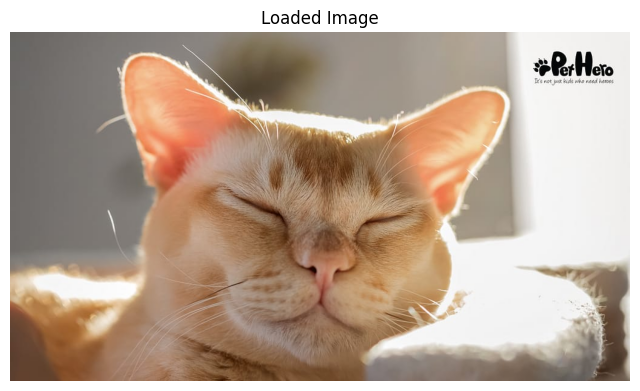

In [5]:
# Function to load image from URL with error handling
def load_image_from_url(url):
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()  # Raise error for bad status codes
        img = Image.open(BytesIO(response.content))
        return img
    except requests.exceptions.RequestException as e:
        print(f"Error loading image: {e}")
        return None
    except Exception as e:
        print(f"Error processing image: {e}")
        return None

##########################################################################################################
# Student change point: choose ONE image source, then rerun the cell.
# Option 1: paste a different direct image URL.
# Option 2: if the internet is unavailable, paste a local image path.
# After changing it, inspect the image size, colors, and whether later cells still work.

url = "https://mlo1wbhvgmgt.i.optimole.com/w:1024/h:576/q:mauto/g:sm/f:best/https://pethero.co.za/wp-content/uploads/2026/02/Indoor-Cats-Blog-Banner.png"
local_image_path = None  # Example: r"C:\\Users\\YourName\\Pictures\\device_image.png"

###########################################################################################################

if local_image_path:
    img = Image.open(local_image_path)
else:
    img = load_image_from_url(url)

if img:
    print("Image loaded successfully!")
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title("Loaded Image")
    plt.axis('off')
    plt.show()
else:
    print("Failed to load image")

## 2. Understanding Image Properties

Every image has properties that define its structure and content. Let's explore the key attributes.

In [6]:
# Check if image was loaded
if img is None:
    print("No image loaded. Please check the URL and try again.")
else:
    # Basic properties
    print(f"Image size: {img.size}")  # (width, height)
    print(f"Image mode: {img.mode}")  # Color mode
    print(f"Image format: {img.format}")  # File format
    
    # Convert to numpy array for shape analysis
    img_array = np.array(img)
    print(f"Array shape: {img_array.shape}")  # (height, width, channels)
    print(f"Array dtype: {img_array.dtype}")
    print(f"Value range: {img_array.min()} to {img_array.max()}")

Image size: (1024, 576)
Image mode: RGB
Image format: JPEG
Array shape: (576, 1024, 3)
Array dtype: uint8
Value range: 0 to 255


## 3. Color Mode Exploration and Conversions

Images can be represented in different color spaces. Understanding these is crucial for preprocessing.

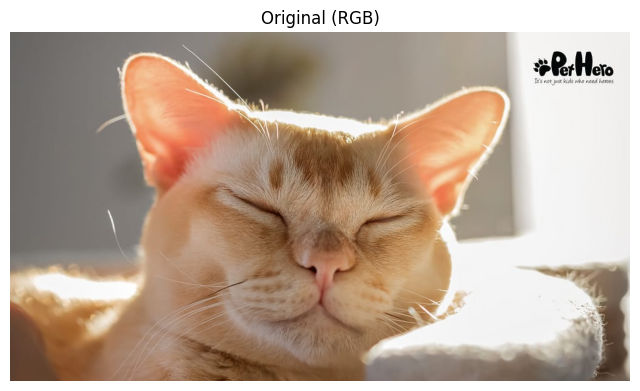

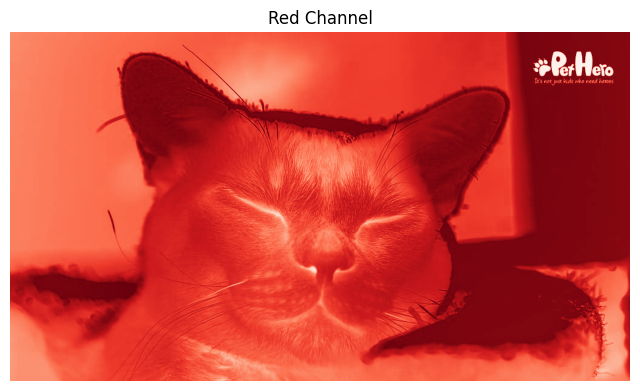

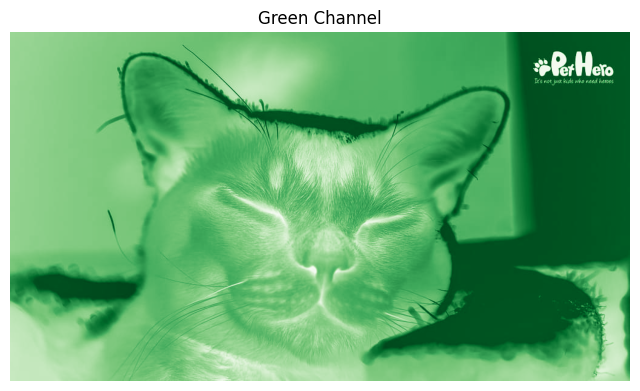

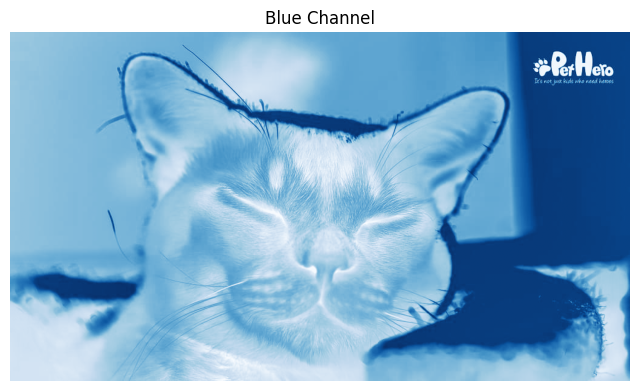

Grayscale mode: L


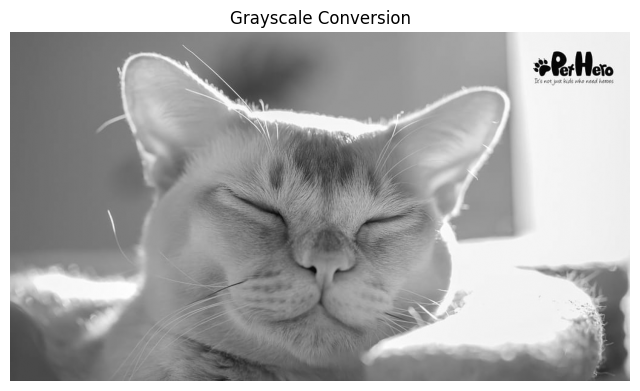

In [7]:
# Explore color channels
if img and img.mode == 'RGB':
    # Split into channels
    r, g, b = img.split()
    
    # Display each channel separately
    channels = [('Original (RGB)', img, None), ('Red Channel', r, 'Reds'), 
                ('Green Channel', g, 'Greens'), ('Blue Channel', b, 'Blues')]
    
    for title, channel_img, cmap in channels:
        plt.figure(figsize=(8, 6))
        if cmap:
            plt.imshow(channel_img, cmap=cmap)
        else:
            plt.imshow(channel_img)
        plt.title(title)
        plt.axis('off')
        plt.show()
    
    # Convert to grayscale
    gray_img = img.convert('L')
    print(f"Grayscale mode: {gray_img.mode}")
    
    plt.figure(figsize=(8, 6))
    plt.imshow(gray_img, cmap='gray')
    plt.title('Grayscale Conversion')
    plt.axis('off')
    plt.show()

## 4. Resizing and Dimension Reduction

Resizing is essential for creating uniform datasets and reducing computational requirements.

Original size: (1024, 576)
Aspect preserved size: (200, 112)


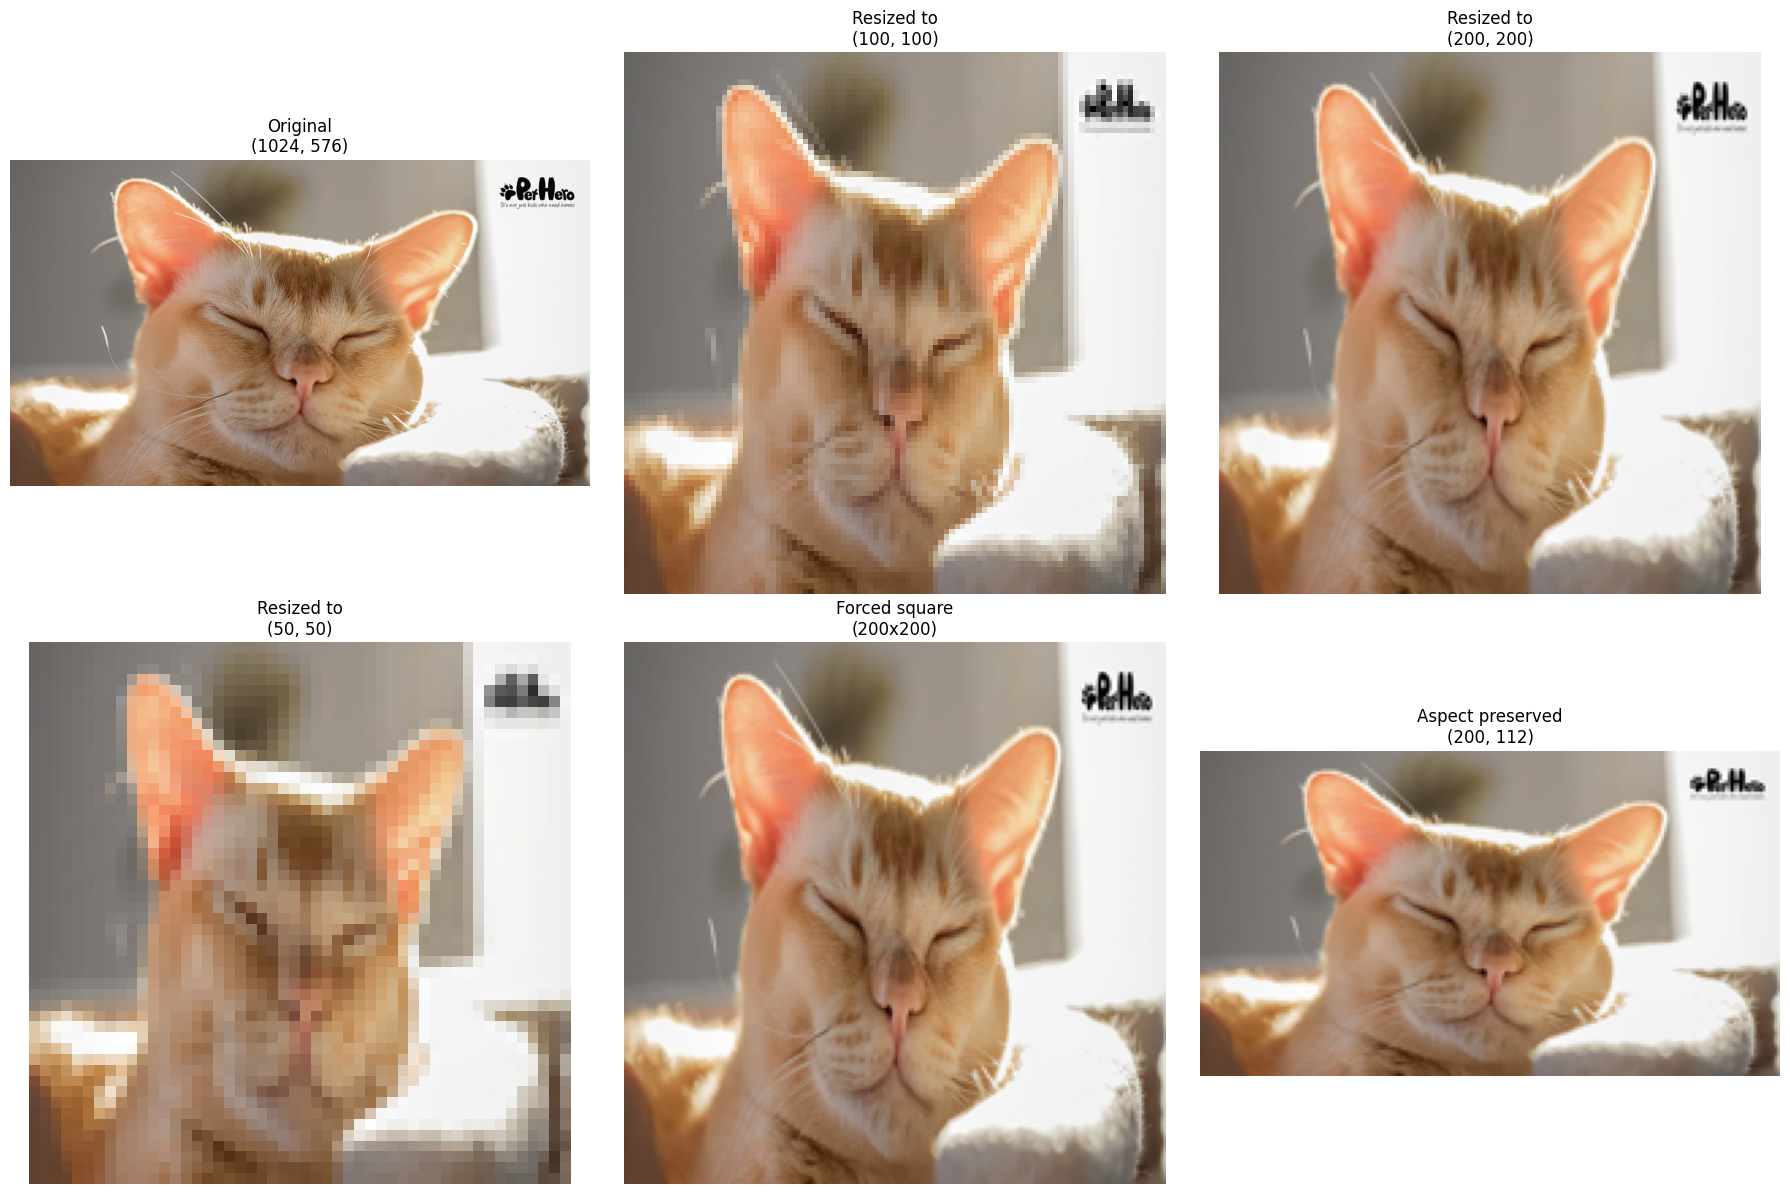

In [15]:
# Resizing examples
from PIL.Image import Resampling


if img:
    original_size = img.size
    print(f"Original size: {original_size}")
############################################################################################################################

    # Student change point: try smaller and larger sizes, and different resampling methods.
    # Inspect when the image becomes too blurry or distorted for a model to use.
    sizes = [(100, 100), (200, 200), (50,50)]
    
    # Resample options: Resampling.NEAREST, Resampling.BILINEAR, Resampling.BICUBIC, Resampling.HAMMING
    resampling = Resampling.BICUBIC  # Change this to try different methods

#############################################################################################################################
    # Aspect ratio preservation helper
    def resize_keep_aspect(img, max_size):
        """Resize while maintaining aspect ratio"""
        width, height = img.size
        if width > height:
            new_width = max_size
            new_height = int(height * max_size / width)
        else:
            new_height = max_size
            new_width = int(width * max_size / height)
        return img.resize((new_width, new_height))
    
    aspect_preserved = resize_keep_aspect(img, 200)
    square_200 = img.resize((200, 200), resample = resampling)
    print(f"Aspect preserved size: {aspect_preserved.size}")
    
    # Combined subplot figure for all resizing examples
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    # Original image
    axes[0].imshow(img)
    axes[0].set_title(f'Original\n{original_size}')
    axes[0].axis('off')
    
    # Resized versions
    for i, size in enumerate(sizes):
        resized = img.resize(size)
        axes[i+1].imshow(resized)
        axes[i+1].set_title(f'Resized to\n{size}')
        axes[i+1].axis('off')
    
    # Forced square and aspect preserved
    axes[4].imshow(square_200)
    axes[4].set_title('Forced square\n(200x200)')
    axes[4].axis('off')
    
    axes[5].imshow(aspect_preserved)
    axes[5].set_title(f'Aspect preserved\n{aspect_preserved.size}')
    axes[5].axis('off')
    
    plt.tight_layout()
    plt.show()

## 4.5. SVD for Image Compression

Singular Value Decomposition (SVD) can be used for image compression by approximating the image using only the most significant singular values. This section demonstrates SVD-based compression for both grayscale and RGB images.

Original image size: (1024, 576)
SVD demo image size: (1024, 576)
Grayscale image shape: (576, 1024)
Data type: float32
Value range: 0.0 - 255.0


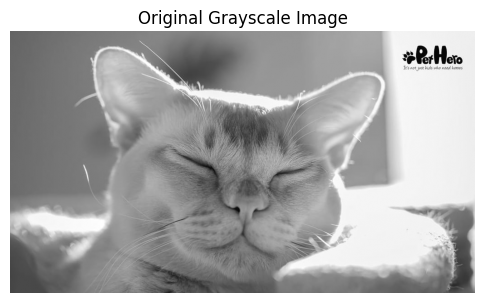

In [16]:
# SVD for Image Compression - Setup
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Full-size photos can make SVD allocate a huge amount of memory.
# Use a teaching-size copy so the demo stays responsive in a notebook.
################################################################################################

# Student change point: lower this for faster demos, raise it to preserve more detail.

# Very large values can make SVD slow or memory-heavy.
SVD_IMAGE_MAX_SIDE = 2000

#################################################################################################
def make_svd_demo_image(image, max_side=SVD_IMAGE_MAX_SIDE):
    demo_image = image.copy()
    demo_image.thumbnail((max_side, max_side), Image.Resampling.LANCZOS)
    return demo_image

# Convert image to grayscale for SVD demo
if img:
    svd_img = make_svd_demo_image(img)
    gray_img = svd_img.convert('L')  # Convert to grayscale
    gray_array = np.array(gray_img, dtype=np.float32)
    
    print(f"Original image size: {img.size}")
    print(f"SVD demo image size: {svd_img.size}")
    print(f"Grayscale image shape: {gray_array.shape}")
    print(f"Data type: {gray_array.dtype}")
    print(f"Value range: {gray_array.min()} - {gray_array.max()}")
    
    # Display original grayscale
    plt.figure(figsize=(6, 6))
    plt.imshow(gray_array, cmap='gray')
    plt.title('Original Grayscale Image')
    plt.axis('off')
    plt.show()


U shape: (576, 576)
Sigma shape: (576,)
V^T shape: (576, 1024)


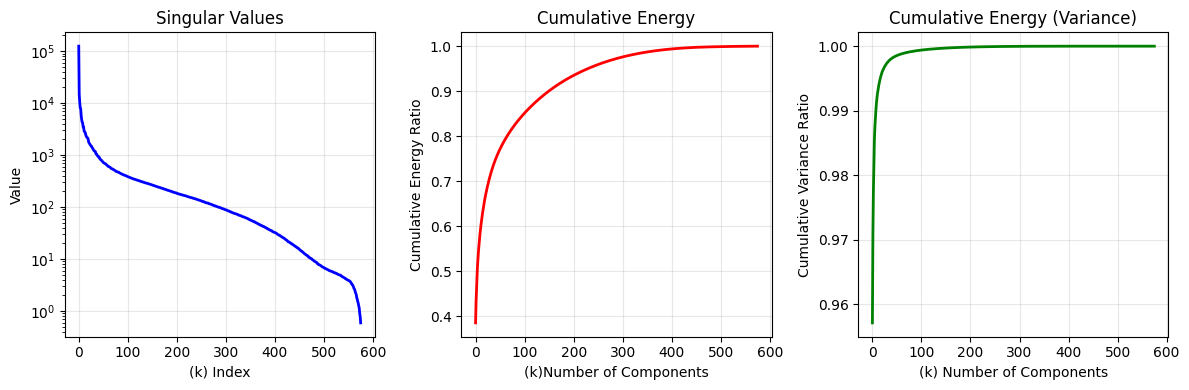


Total elements in original image: 589824
k=10: Compression ratio = 0.027, Energy retained = 0.992
k=50: Compression ratio = 0.136, Energy retained = 0.999
k=100: Compression ratio = 0.271, Energy retained = 0.999
k=200: Compression ratio = 0.543, Energy retained = 1.000


In [17]:
# SVD Decomposition and Singular Value Analysis
if 'gray_array' in locals():
    try:
        # Perform SVD on the resized teaching image.
        U, s, Vt = np.linalg.svd(gray_array, full_matrices=False)
    except np.linalg.LinAlgError as error:
        U = s = Vt = None
        print(f"SVD did not converge: {error}")
    else:
        print(f"U shape: {U.shape}")
        print(f"Sigma shape: {s.shape}")
        print(f"V^T shape: {Vt.shape}")
        
        # Plot singular values
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 3, 1)
        plt.plot(s, 'b-', linewidth=2)
        plt.title('Singular Values')
        plt.xlabel('(k) Index')
        plt.ylabel('Value')
        plt.yscale('log')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 3, 2)
        plt.plot(np.cumsum(s) / np.sum(s), 'r-', linewidth=2)
        plt.title('Cumulative Energy')
        plt.xlabel('(k)Number of Components')
        plt.ylabel('Cumulative Energy Ratio')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 3, 3)
        plt.plot(np.cumsum(s**2) / np.sum(s**2), 'g-', linewidth=2)
        plt.title('Cumulative Energy (Variance)')
        plt.xlabel('(k) Number of Components')
        plt.ylabel('Cumulative Variance Ratio')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print compression ratios
        total_elements = np.prod(gray_array.shape)
        print(f"\nTotal elements in original image: {total_elements}")
        
        for k in [10, 50, 100, 200]:
            if k <= len(s):
                compressed_elements = k * (U.shape[0] + Vt.shape[1]) + k
                ratio = compressed_elements / total_elements
                energy = np.sum(s[:k]**2) / np.sum(s**2)
                print(f"k={k}: Compression ratio = {ratio:.3f}, Energy retained = {energy:.3f}")


ValueError: num must be an integer with 1 <= num <= 8, not 9

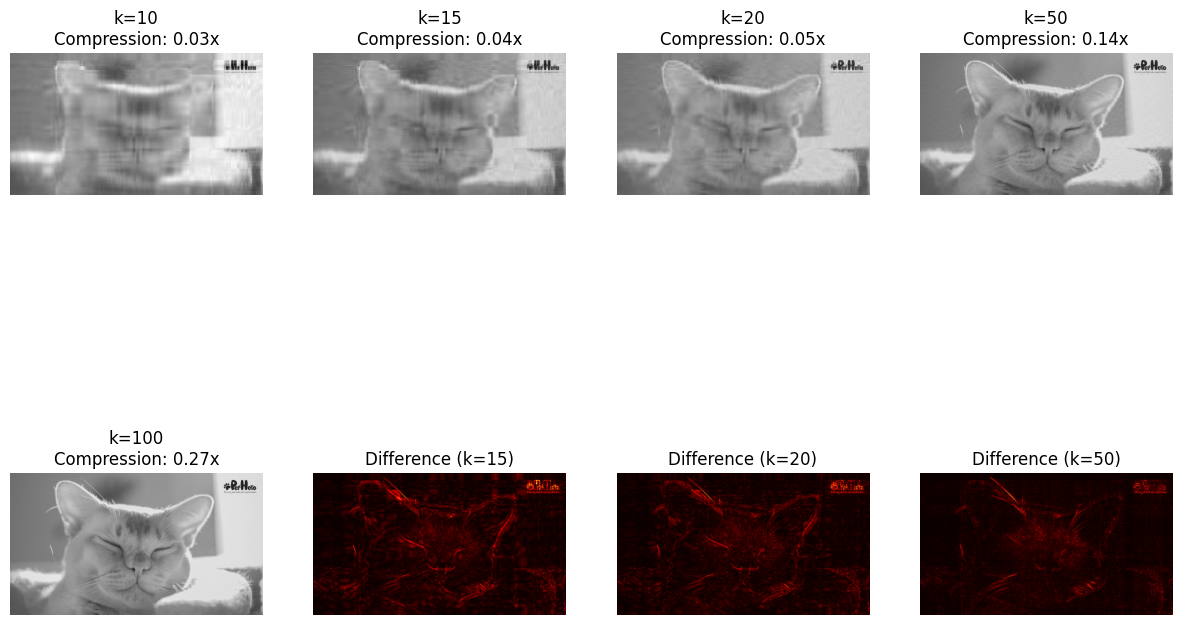

In [21]:
# Image Reconstruction with Different k Values (Grayscale)
if 'U' in locals() and 's' in locals() and 'Vt' in locals() and U is not None:
########################################################################################
    # Student change point: change these k values.
    # Smaller k uses less information; larger k keeps more detail.
    k_values = [k for k in [10,15,20, 50, 100, 200] if k <= len(s)]


######################################################################################## 
    plt.figure(figsize=(15, 10))
    
    for i, k in enumerate(k_values):
        # Reconstruct image using first k components
        reconstructed = (U[:, :k] * s[:k]) @ Vt[:k, :]
        
        # Calculate compression metrics
        original_size = gray_array.nbytes
        compressed_size = (U[:, :k].nbytes + s[:k].nbytes + Vt[:k, :].nbytes)
        compression_ratio = compressed_size / original_size
        
        plt.subplot(2, 4, i+1)
        plt.imshow(reconstructed, cmap='gray')
        plt.title(f'k={k}\nCompression: {compression_ratio:.2f}x')
        plt.axis('off')
        
        # Plot difference
        diff = np.abs(gray_array - reconstructed)
        plt.subplot(2, 4, i+5)
        plt.imshow(diff, cmap='hot')
        plt.title(f'Difference (k={k})')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Quantitative analysis
    print("Reconstruction Quality Analysis:")
    for k in k_values:
        reconstructed = (U[:, :k] * s[:k]) @ Vt[:k, :]
        mse = np.mean((gray_array - reconstructed)**2)
        psnr = 20 * np.log10(255.0 / np.sqrt(mse)) if mse > 0 else float('inf')
        energy_retained = np.sum(s[:k]**2) / np.sum(s**2)
        print(f"k={k}: MSE={mse:.2f}, PSNR={psnr:.2f}dB, Energy={energy_retained:.3f}")


RGB image shape: (576, 1024, 3)


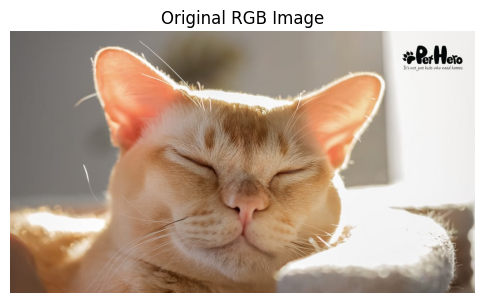

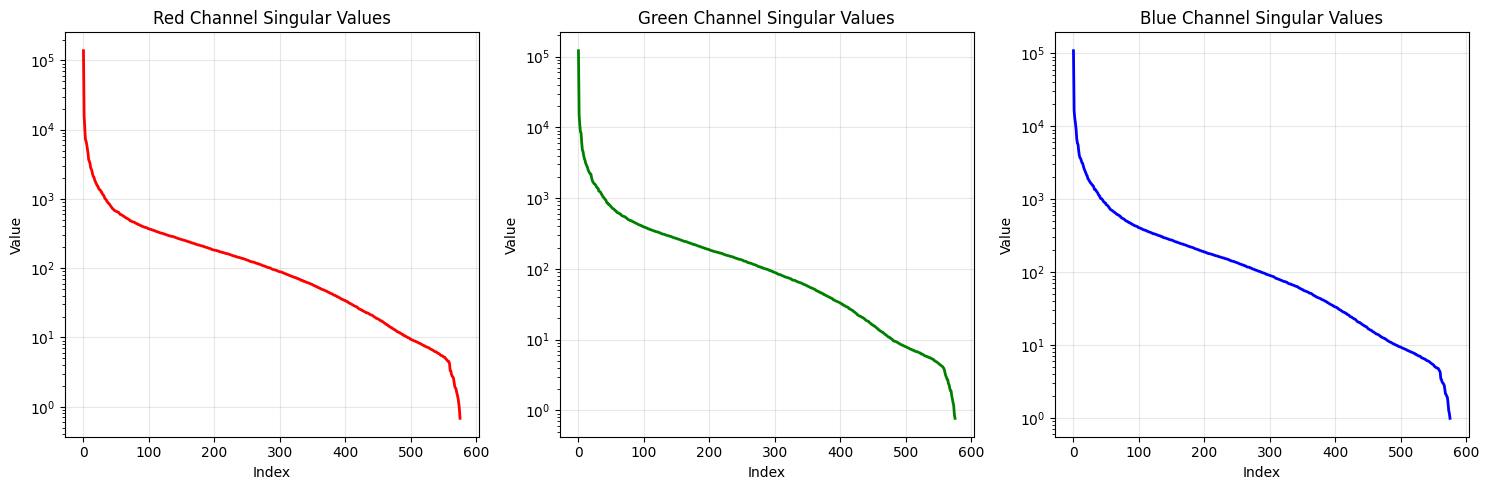

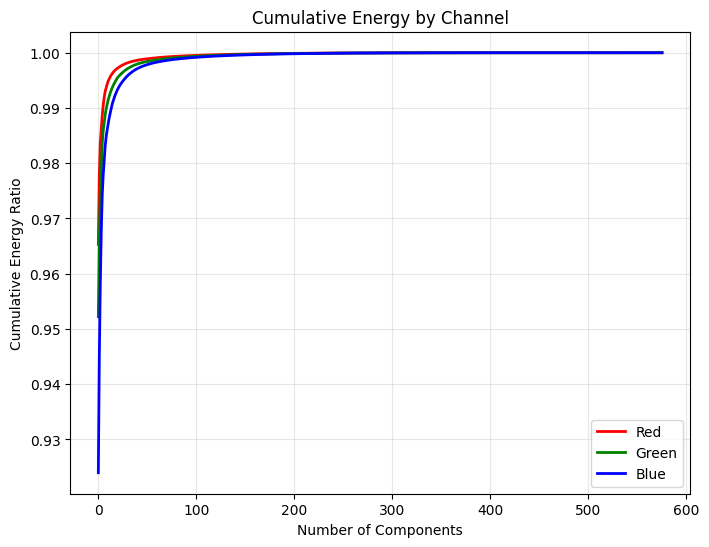

In [22]:
# SVD for RGB Images
if 'svd_img' in locals():
    # Convert the resized teaching image to an RGB array.
    rgb_array = np.array(svd_img.convert("RGB"), dtype=np.float32)
    if rgb_array.ndim == 3 and rgb_array.shape[2] == 3:
        print(f"RGB image shape: {rgb_array.shape}")
        
        # Display original RGB
        plt.figure(figsize=(6, 6))
        plt.imshow(rgb_array.astype(np.uint8))
        plt.title('Original RGB Image')
        plt.axis('off')
        plt.show()
        
        # SVD for each color channel
        U_channels = []
        s_channels = []
        Vt_channels = []
        
        try:
            for c in range(3):
                U_c, s_c, Vt_c = np.linalg.svd(rgb_array[:, :, c], full_matrices=False)
                U_channels.append(U_c)
                s_channels.append(s_c)
                Vt_channels.append(Vt_c)
        except np.linalg.LinAlgError as error:
            U_channels = s_channels = Vt_channels = None
            print(f"RGB SVD did not converge: {error}")
        else:
            # Plot singular values for each channel
            colors = ['red', 'green', 'blue']
            channel_names = ['Red', 'Green', 'Blue']
            
            plt.figure(figsize=(15, 5))
            for c in range(3):
                plt.subplot(1, 3, c+1)
                plt.plot(s_channels[c], color=colors[c], linewidth=2)
                plt.title(f'{channel_names[c]} Channel Singular Values')
                plt.xlabel('Index')
                plt.ylabel('Value')
                plt.yscale('log')
                plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            # Cumulative energy for each channel
            plt.figure(figsize=(8, 6))
            for c in range(3):
                cumulative = np.cumsum(s_channels[c]**2) / np.sum(s_channels[c]**2)
                plt.plot(cumulative, color=colors[c], linewidth=2, label=channel_names[c])
            plt.title('Cumulative Energy by Channel')
            plt.xlabel('Number of Components')
            plt.ylabel('Cumulative Energy Ratio')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()


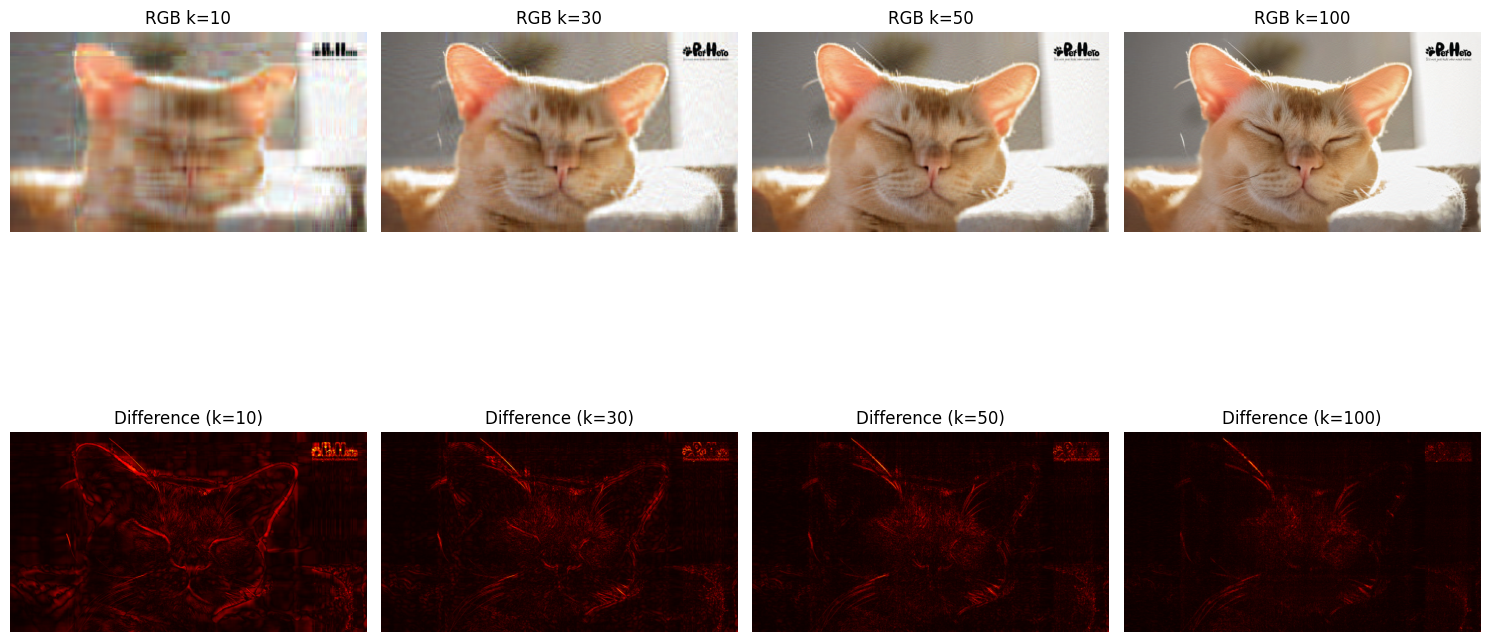

RGB Reconstruction Quality Analysis:
k=10: MSE=245.34, PSNR=24.23dB, Avg Energy=0.990
k=30: MSE=78.08, PSNR=29.21dB, Avg Energy=0.997
k=50: MSE=42.30, PSNR=31.87dB, Avg Energy=0.998
k=100: MSE=17.24, PSNR=35.77dB, Avg Energy=0.999

SVD-based image compression allows you to:
- Reduce storage requirements by keeping only dominant components
- Control compression quality by choosing k
- Achieve better quality than pixel-based compression for the same ratio
- Apply different compression levels per color channel


In [23]:
# RGB Image Reconstruction with SVD
if 'U_channels' in locals() and 's_channels' in locals() and 'Vt_channels' in locals() and U_channels is not None:
    max_rgb_k = min(len(channel_s) for channel_s in s_channels)
#############################################################################
    # Student change point: compare low and high k values for color images.
    k_values_rgb = [k for k in [10, 30, 50, 100] if k <= max_rgb_k]
############################################################################
    plt.figure(figsize=(15, 10))
    
    for i, k in enumerate(k_values_rgb):
        # Reconstruct each channel
        reconstructed_channels = []
        for c in range(3):
            reconstructed = (U_channels[c][:, :k] * s_channels[c][:k]) @ Vt_channels[c][:k, :]
            reconstructed_channels.append(reconstructed)
        
        # Combine channels
        reconstructed_rgb = np.stack(reconstructed_channels, axis=2)
        reconstructed_rgb = np.clip(reconstructed_rgb, 0, 255).astype(np.uint8)
        
        plt.subplot(2, 4, i+1)
        plt.imshow(reconstructed_rgb)
        plt.title(f'RGB k={k}')
        plt.axis('off')
        
        # Show difference
        diff_rgb = np.abs(rgb_array.astype(np.float32) - reconstructed_rgb.astype(np.float32))
        diff_gray = np.mean(diff_rgb, axis=2)  # Convert to grayscale for visualization
        plt.subplot(2, 4, i+5)
        plt.imshow(diff_gray, cmap='hot')
        plt.title(f'Difference (k={k})')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Quantitative analysis for RGB
    print("RGB Reconstruction Quality Analysis:")
    for k in k_values_rgb:
        reconstructed_channels = []
        for c in range(3):
            reconstructed = (U_channels[c][:, :k] * s_channels[c][:k]) @ Vt_channels[c][:k, :]
            reconstructed_channels.append(reconstructed)
        
        reconstructed_rgb = np.stack(reconstructed_channels, axis=2)
        mse = np.mean((rgb_array - reconstructed_rgb)**2)
        psnr = 20 * np.log10(255.0 / np.sqrt(mse)) if mse > 0 else float('inf')
        
        # Average energy retained across channels
        energy_retained = np.mean([np.sum(s_channels[c][:k]**2) / np.sum(s_channels[c]**2) for c in range(3)])
        print(f"k={k}: MSE={mse:.2f}, PSNR={psnr:.2f}dB, Avg Energy={energy_retained:.3f}")
    
    print("\nSVD-based image compression allows you to:")
    print("- Reduce storage requirements by keeping only dominant components")
    print("- Control compression quality by choosing k")
    print("- Achieve better quality than pixel-based compression for the same ratio")
    print("- Apply different compression levels per color channel")


## 4.6. SVD for Image Denoising

SVD can also be used for denoising images. By keeping only the top k components, we can remove noise while preserving the main image structure, since noise typically has low energy and gets distributed across higher components.

Added Gaussian noise with std=50
Noisy image range: 0.0 to 255.0


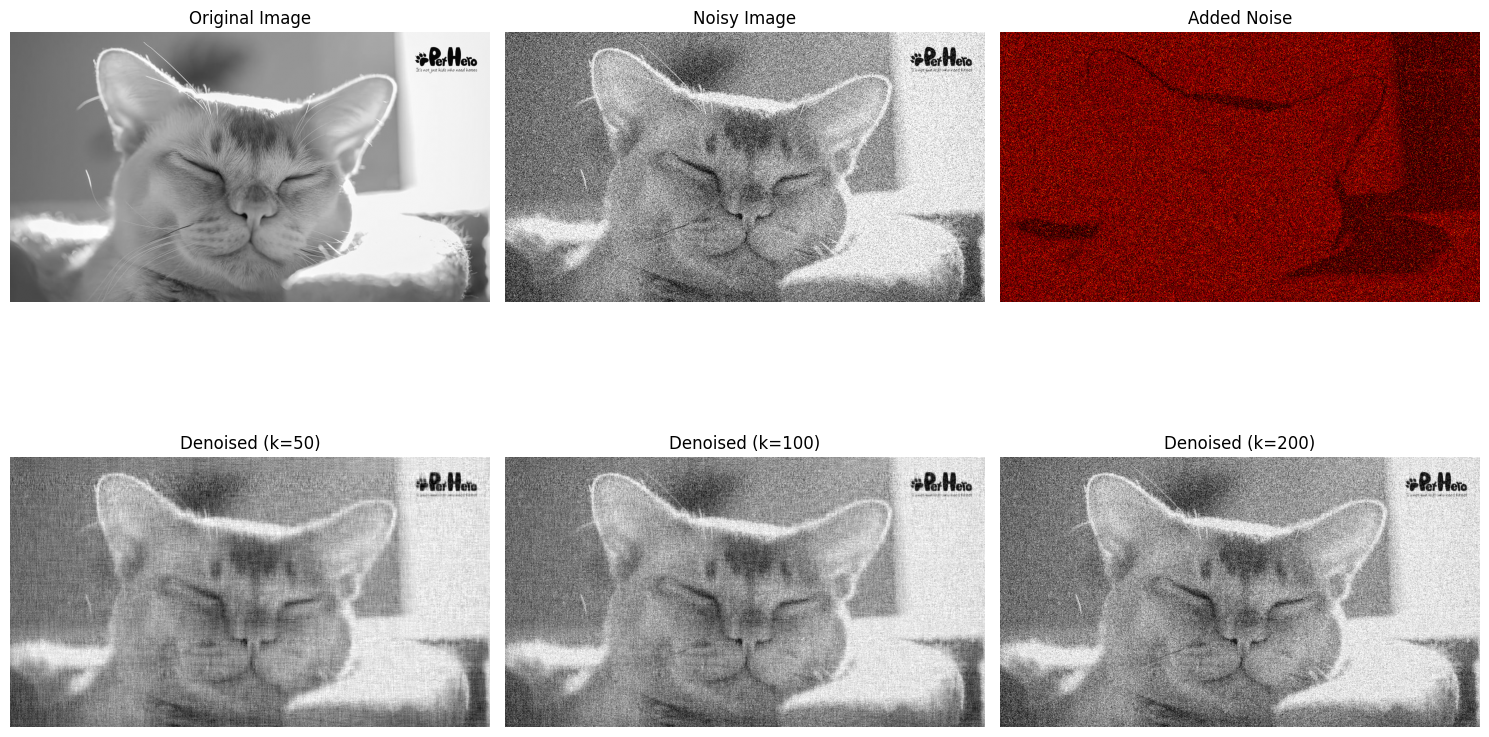


=== Denoising Quality Analysis (SVD) ===
We compare each denoised image against:
1) the original clean image (best reference for true quality)
2) the noisy input image (shows how much the result changed)

Metric guide:
- MSE (Mean Squared Error): average squared pixel difference
  Lower MSE is better (0 means identical).
- PSNR (Peak Signal-to-Noise Ratio, in dB): quality derived from MSE
  Higher PSNR is better.

--- k = 50 singular values kept ---
vs ORIGINAL (clean target):
  MSE  = 542.91  (lower is better)
  PSNR = 20.78 dB (higher is better)
vs NOISY input:
  MSE  = 1747.35
  PSNR = 15.71 dB
Interpretation: moderate reconstruction

--- k = 100 singular values kept ---
vs ORIGINAL (clean target):
  MSE  = 891.96  (lower is better)
  PSNR = 18.63 dB (higher is better)
vs NOISY input:
  MSE  = 1335.74
  PSNR = 16.87 dB
Interpretation: low reconstruction quality

--- k = 200 singular values kept ---
vs ORIGINAL (clean target):
  MSE  = 1404.38  (lower is better)
  PSNR = 16.66 dB (h

In [24]:
# SVD for Image Denoising
if 'gray_array' in locals():
    # Add low-magnitude noise to the image
#########################################################
#  Student change point: adjust this value to change noise intensity.
    noise_level = 50
#########################################################
    
    np.random.seed(150)  # For reproducibility
    noise = np.random.normal(0, noise_level, gray_array.shape)
    # Set some random pixels to 0 to have a mix of noisy and clean areas.
    mask = np.random.rand(*gray_array.shape) < 0.01  # 99% of pixels will be clean
    noise[mask] = 0
    noisy_image = gray_array + noise
    noisy_image = np.clip(noisy_image, 0, 255)  # Keep values in valid range
    try:
        U_n, s_n, Vt_n = np.linalg.svd(noisy_image, full_matrices=False)
    except np.linalg.LinAlgError as error:
        print(f"Denoising SVD did not converge: {error}")
    else:
        print(f"Added Gaussian noise with std={noise_level}")
        print(f"Noisy image range: {noisy_image.min():.1f} to {noisy_image.max():.1f}")
######################################################### Inspect whether SVD denoising helps or removes useful image detail.        
        # Student change point: adjust the k values below to see how it affects denoising quality.
        k_denoise_values = [k for k in [50, 100, 200] if k <= len(s_n)]
##########################################################
        # Display original, noisy, and denoised images
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # Original
        axes[0,0].imshow(gray_array, cmap='gray')
        axes[0,0].set_title('Original Image')
        axes[0,0].axis('off')
        
        # Noisy
        axes[0,1].imshow(noisy_image, cmap='gray')
        axes[0,1].set_title('Noisy Image')
        axes[0,1].axis('off')
        
        # Difference (noise)
        noise_diff = np.abs(gray_array - noisy_image)
        axes[0,2].imshow(noise_diff, cmap='hot')
        axes[0,2].set_title('Added Noise')
        axes[0,2].axis('off')
        
        
        # Denoise using SVD with different k values
        
        
        for i, k in enumerate(k_denoise_values):
            # Reconstruct with k components
            denoised = (U_n[:, :k] * s_n[:k]) @ Vt_n[:k, :]
            denoised = np.clip(denoised, 0, 255)
            
            axes[1,i].imshow(denoised, cmap='gray')
            axes[1,i].set_title(f'Denoised (k={k})')
            axes[1,i].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Quantitative comparison (beginner-friendly output)
        print("\n=== Denoising Quality Analysis (SVD) ===")
        print("We compare each denoised image against:")
        print("1) the original clean image (best reference for true quality)")
        print("2) the noisy input image (shows how much the result changed)\n")
        
        print("Metric guide:")
        print("- MSE (Mean Squared Error): average squared pixel difference")
        print("  Lower MSE is better (0 means identical).")
        print("- PSNR (Peak Signal-to-Noise Ratio, in dB): quality derived from MSE")
        print("  Higher PSNR is better.\n")
        
        best_k = None # Track which k gives the best PSNR vs original 
        best_psnr = -np.inf
        
        for k in k_denoise_values:
            denoised = (U_n[:, :k] * s_n[:k]) @ Vt_n[:k, :]
            denoised = np.clip(denoised, 0, 255)
        
            # Error compared to clean/original image
            mse_original = np.mean((gray_array - denoised) ** 2)
        
            # Error compared to noisy input image
            mse_noisy = np.mean((noisy_image - denoised) ** 2)
        
            psnr_original = 20 * np.log10(255.0 / np.sqrt(mse_original)) if mse_original > 0 else float('inf')
            psnr_noisy = 20 * np.log10(255.0 / np.sqrt(mse_noisy)) if mse_noisy > 0 else float('inf')
        
            print(f"--- k = {k} singular values kept ---")
            print(f"vs ORIGINAL (clean target):")
            print(f"  MSE  = {mse_original:.2f}  (lower is better)")
            print(f"  PSNR = {psnr_original:.2f} dB (higher is better)")
        
            print(f"vs NOISY input:")
            print(f"  MSE  = {mse_noisy:.2f}")
            print(f"  PSNR = {psnr_noisy:.2f} dB")
        
            # Optional interpretation line for beginners
            if psnr_original >= 40:
                quality_note = "very high quality reconstruction"
            elif psnr_original >= 30:
                quality_note = "good reconstruction"
            elif psnr_original >= 20:
                quality_note = "moderate reconstruction"
            else:
                quality_note = "low reconstruction quality"
            print(f"Interpretation: {quality_note}\n")
        
            if psnr_original > best_psnr:
                best_psnr = psnr_original
                best_k = k
        
        print("Summary:")
        print(f"- Best k by PSNR vs original: k = {best_k} (PSNR = {best_psnr:.2f} dB)")
        print("- In denoising, we usually trust metrics vs ORIGINAL most.")
        print("- A lower PSNR vs NOISY can be normal because denoising intentionally changes noisy pixels.")
        
        print("\nWhy SVD denoising works:")
        print("- Early singular components capture major image structure (signal).")
        print("- Noise is spread across many components, especially weaker/high-order ones.")
        print("- Keeping only the first k components removes much of the noise while preserving structure.")


## 4.7. PCA for Image Groups

SVD helped us compress one image. PCA helps us compare many images at once.

In this section, each image is resized, converted to grayscale or RGB, flattened into one long row of pixel values, and reduced to two or three PCA coordinates. The scatter plot is not a classifier. It is a visual question: do the images already form groups before we train a model?

**Student change points:** choose `PCA_PLOT_DIMENSIONS = 2` or `3`, then try changing `PCA_IMAGE_SIZE`, `PCA_COLOR_MODE`, or `MAX_PCA_IMAGES`. Inspect whether the groups become more or less separated.


In [26]:
# PCA for Image Groups
import base64
from io import BytesIO
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from bokeh.io import output_notebook, show
from bokeh.models import ColumnDataSource, HoverTool, Span
from bokeh.palettes import Category10, Category20
from bokeh.plotting import figure
from sklearn.decomposition import PCA
##########################################################################################################

# Student change point: choose 2 for an interactive thumbnail hover plot or 3 for a rotatable 3D plot.
# In the 2D Bokeh view, hover over a point to see the matching image.
# In the 3D Plotly view, drag to rotate, scroll to zoom, and hover to see the image path.
PCA_PLOT_DIMENSIONS = 3

# Student change point: smaller is faster; larger may preserve more detail.
PCA_IMAGE_SIZE = 1000

# Student change point: try "grayscale" first, then "rgb" if you want color information.
PCA_COLOR_MODE = "grayscale"

# Student change point: use fewer images for speed, or more images for a fuller picture.
MAX_PCA_IMAGES = 60
#############################################################################################################
if PCA_PLOT_DIMENSIONS not in [2, 3]:
    raise ValueError("PCA_PLOT_DIMENSIONS must be 2 or 3.")

# Look for the workshop image dataset from inside the notebook folder.
notebook_dir = Path.cwd()
if notebook_dir.name == "0_Class_Notebooks":
    repo_root = notebook_dir.parent
else:
    repo_root = notebook_dir

pca_dataset_root = repo_root / "Device_Images_Nelson"
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

if not pca_dataset_root.exists():
    print(f"Dataset folder not found: {pca_dataset_root}")
    print("You can still learn PCA later after adding a folder of images.")
else:
    image_paths = sorted(
        path for path in pca_dataset_root.rglob("*")
        if path.is_file() and path.suffix.lower() in valid_extensions
    )[:MAX_PCA_IMAGES]

    pca_rows = []
    pca_labels = []
    pca_hover_names = []
    pca_thumbnail_sources = []

    for image_path in image_paths:
        try:
            with Image.open(image_path) as image_file:
                hover_image = image_file.convert("RGB")
                hover_image.thumbnail((160, 160))
                thumbnail_buffer = BytesIO()
                hover_image.save(thumbnail_buffer, format="PNG")
                thumbnail_source = "data:image/png;base64," + base64.b64encode(thumbnail_buffer.getvalue()).decode("ascii")

                if PCA_COLOR_MODE == "rgb":
                    prepared = image_file.convert("RGB").resize((PCA_IMAGE_SIZE, PCA_IMAGE_SIZE))
                    array = np.array(prepared, dtype=np.float32) / 255.0
                else:
                    prepared = image_file.convert("L").resize((PCA_IMAGE_SIZE, PCA_IMAGE_SIZE))
                    array = np.array(prepared, dtype=np.float32) / 255.0
        except Exception as error:
            print(f"Skipping unreadable image {image_path.name}: {error}")
            continue

        # Each image becomes one long row of pixel values.
        pca_rows.append(array.flatten())

        # Use the top-level folder name as a simple label for plotting colors.
        label = image_path.relative_to(pca_dataset_root).parts[0]
        pca_labels.append(label)
        pca_hover_names.append(str(image_path.relative_to(pca_dataset_root)))
        pca_thumbnail_sources.append(thumbnail_source)

    if len(pca_rows) <= PCA_PLOT_DIMENSIONS:
        print(f"Need more than {PCA_PLOT_DIMENSIONS} readable images for a useful PCA plot.")
    else:
        X_pca_images = np.vstack(pca_rows)
        pca = PCA(n_components=PCA_PLOT_DIMENSIONS, random_state=42)
        X_pca_view = pca.fit_transform(X_pca_images)

        print(f"Images used: {len(pca_rows)}")
        print(f"Flattened image table shape: {X_pca_images.shape}")
        print(f"PCA coordinates shape: {X_pca_view.shape}")
        print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
        print(f"Total variation shown in this {PCA_PLOT_DIMENSIONS}D plot: {pca.explained_variance_ratio_.sum():.2%}")

        unique_labels = sorted(set(pca_labels))
        labels_array = np.array(pca_labels)
        hover_names_array = np.array(pca_hover_names)
        thumbnail_sources_array = np.array(pca_thumbnail_sources)
        cmap = plt.get_cmap("tab10")

        if PCA_PLOT_DIMENSIONS == 2:
            output_notebook()
            palette = Category10[10] if len(unique_labels) <= 10 else Category20[20]
            hover_tool = HoverTool(
                tooltips="""
                <div style="width: 185px;">
                    <div style="font-weight: 700; margin-bottom: 4px;">@image_name</div>
                    <div style="font-size: 12px; margin-bottom: 6px; color: #555;">Folder: @folder</div>
                    <img src="@thumbnail" style="width: 160px; max-height: 160px; object-fit: contain; border: 1px solid #ddd;" />
                    <div style="font-size: 12px; margin-top: 6px; color: #555;">PC1: @pc1{0.000}</div>
                    <div style="font-size: 12px; color: #555;">PC2: @pc2{0.000}</div>
                </div>
                """
            )
            pca_figure = figure(
                title="Interactive 2D PCA view of image groups",
                width=900,
                height=700,
                tools=[hover_tool, "pan", "wheel_zoom", "box_zoom", "reset", "save"],
                x_axis_label="PCA component 1",
                y_axis_label="PCA component 2",
            )

            for i, label in enumerate(unique_labels):
                mask = labels_array == label
                source = ColumnDataSource(
                    data={
                        "pc1": X_pca_view[mask, 0],
                        "pc2": X_pca_view[mask, 1],
                        "folder": labels_array[mask],
                        "image_name": hover_names_array[mask],
                        "thumbnail": thumbnail_sources_array[mask],
                    }
                )
                pca_figure.scatter(
                    x="pc1",
                    y="pc2",
                    source=source,
                    legend_label=label,
                    marker="circle",
                    size=10,
                    alpha=0.8,
                    color=palette[i % len(palette)],
                )

            pca_figure.add_layout(Span(location=0, dimension="width", line_color="gray", line_alpha=0.4))
            pca_figure.add_layout(Span(location=0, dimension="height", line_color="gray", line_alpha=0.4))
            pca_figure.legend.title = "Image folder"
            pca_figure.legend.click_policy = "hide"
            pca_figure.grid.grid_line_alpha = 0.25
            show(pca_figure)
        else:
            fig = go.Figure()

            for i, label in enumerate(unique_labels):
                mask = labels_array == label
                rgba = cmap(i % 10)
                color = f"rgb({int(rgba[0] * 255)}, {int(rgba[1] * 255)}, {int(rgba[2] * 255)})"
                fig.add_trace(
                    go.Scatter3d(
                        x=X_pca_view[mask, 0],
                        y=X_pca_view[mask, 1],
                        z=X_pca_view[mask, 2],
                        mode="markers",
                        name=label,
                        text=hover_names_array[mask],
                        hovertemplate=(
                            "Image: %{text}<br>"
                            "PC1: %{x:.3f}<br>"
                            "PC2: %{y:.3f}<br>"
                            "PC3: %{z:.3f}<extra></extra>"
                        ),
                        marker={"size": 6, "opacity": 0.82, "color": color},
                    )
                )

            fig.update_layout(
                title="Interactive 3D PCA view of image groups",
                legend_title_text="Image folder",
                width=900,
                height=700,
                margin={"l": 0, "r": 0, "b": 0, "t": 50},
                scene={
                    "xaxis_title": "PCA component 1",
                    "yaxis_title": "PCA component 2",
                    "zaxis_title": "PCA component 3",
                },
            )
            fig.show(config={"scrollZoom": True, "displaylogo": False})

Images used: 50
Flattened image table shape: (50, 1000000)
PCA coordinates shape: (50, 3)
Explained variance ratio: [0.19630545 0.13466561 0.10538594]
Total variation shown in this 3D plot: 43.64%


### Interpreting the PCA Plot

Each dot is one image. Dots that land near each other have similar pixel patterns after resizing and flattening.

Ask these questions before moving on:

- Does the 2D or 3D view make the groups easier to see?
- Do images from the same folder cluster together?
- Do defect images separate from clean device images?
- Could the grouping be caused by lighting, background, angle, or image size instead of the device itself?
- If the groups overlap, what might make classification harder later?

PCA is useful for previewing structure, but it does not prove that a classifier will work. It gives us a visual clue about what the model may notice.


## 5. Normalization and Scaling

Normalization transforms pixel values to a standard range, which is crucial for ML algorithms.

In [ ]:
# Show preprocessing steps in color, without per-image rescaling,
# plus histograms so you can see how the pixel distributions change.

import numpy as np
import matplotlib.pyplot as plt

if img:
    img_array = np.array(img.convert("RGB"), dtype=np.float32)

    # Step 1: normalize to [0, 1]
    normalized = img_array / 255.0

    # Step 2: standardize the normalized image, channel-wise
    mean = normalized.mean(axis=(0, 1), keepdims=True)
    std = normalized.std(axis=(0, 1), keepdims=True)
    standardized = (normalized - mean) / std

    # Force all image displays into the same 0..255 byte space
    # without stretching each image to look nice
    original_display = np.clip(img_array, 0, 255).astype(np.uint8)
    normalized_display = np.clip(normalized, 0, 255).astype(np.uint8)
    standardized_display = np.clip(standardized, 0, 255).astype(np.uint8)

    print("Original image stats:")
    print(f"Shape: {img_array.shape}")
    print(f"Min: {img_array.min():.2f}, Max: {img_array.max():.2f}")
    print(f"Channel means: {img_array.mean(axis=(0, 1))}")
    print(f"Channel stds: {img_array.std(axis=(0, 1))}")

    print("\nNormalized image stats:")
    print(f"Min: {normalized.min():.4f}, Max: {normalized.max():.4f}")
    print(f"Channel means: {normalized.mean(axis=(0, 1))}")
    print(f"Channel stds: {normalized.std(axis=(0, 1))}")

    print("\nStandardized image stats:")
    print(f"Min: {standardized.min():.4f}, Max: {standardized.max():.4f}")
    print(f"Channel means: {standardized.mean(axis=(0, 1))}")
    print(f"Channel stds: {standardized.std(axis=(0, 1))}")

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Top row: images
    axes[0, 0].imshow(original_display)
    axes[0, 0].set_title("Original RGB\nDisplayed as 0..255")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(normalized_display)
    axes[0, 1].set_title("Normalized RGB\nClipped into 0..255")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(standardized_display)
    axes[0, 2].set_title("Standardized RGB\nClipped into 0..255")
    axes[0, 2].axis("off")

    # Bottom row: histograms
    colors = ["red", "green", "blue"]
    labels = ["Red", "Green", "Blue"]

    original_flat = img_array.reshape(-1, 3)
    normalized_flat = normalized.reshape(-1, 3)
    standardized_flat = standardized.reshape(-1, 3)

    for c in range(3):
        axes[1, 0].hist(original_flat[:, c], bins=64, alpha=0.45, color=colors[c], label=labels[c])
    axes[1, 0].set_title("Original Pixel Distribution")
    axes[1, 0].set_xlabel("Pixel value (0..255)")
    axes[1, 0].set_ylabel("Pixel count")
    axes[1, 0].set_xlim(0, 255)
    axes[1, 0].legend()

    for c in range(3):
        axes[1, 1].hist(normalized_flat[:, c], bins=64, alpha=0.45, color=colors[c], label=labels[c])
    axes[1, 1].set_title("Normalized Pixel Distribution")
    axes[1, 1].set_xlabel("Pixel value (0..1)")
    axes[1, 1].set_ylabel("Pixel count")
    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].legend()

    for c in range(3):
        axes[1, 2].hist(standardized_flat[:, c], bins=64, alpha=0.45, color=colors[c], label=labels[c])
    axes[1, 2].set_title("Standardized Pixel Distribution")
    axes[1, 2].set_xlabel("Z-score")
    axes[1, 2].set_ylabel("Pixel count")
    axes[1, 2].legend()

    plt.tight_layout()
    plt.show()


## 6. Basic Data Augmentation

Data augmentation creates variations of your images to improve model generalization.

In [ ]:
# Data augmentation with torchvision
if img:
    # Student change point: change flip probability, rotation degrees, or color jitter.
    # Inspect whether the augmented images still look like realistic device images.
    # Define simple augmentation pipeline
    augmentations = transforms.Compose([
        transforms.RandomHorizontalFlip(p=.5),  # Always flip for demo
        transforms.RandomRotation(degrees=30),
        transforms.ColorJitter(brightness=0.2, contrast=0.5, saturation=0.2),
    ])
    
    # Convert PIL to tensor for torchvision
    to_tensor = transforms.ToTensor()
    img_tensor = to_tensor(img)
    
    # Apply augmentations multiple times
    augmented_images = []
    for i in range(4):
        # Re-seed for reproducibility in demo
        torch.manual_seed(i)
        aug_img = augmentations(img_tensor)
        augmented_images.append(aug_img)
    
    # Display augmentations
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes = axes.flatten()
    
    for i, aug_img in enumerate(augmented_images):
        # Convert back to PIL for display
        to_pil = transforms.ToPILImage()
        pil_img = to_pil(aug_img)
        axes[i].imshow(pil_img)
        axes[i].set_title(f'Augmentation {i+1}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

## 7. ML Preparation Concepts

Preparing images for machine learning involves converting them to the right format for your model.

In [ ]:
# ML preparation
if img:
    # Convert to different formats
    pil_img = img
    np_img = np.array(pil_img)
    tensor_img = torch.from_numpy(np_img).permute(2, 0, 1).float() / 255.0  # CHW format
    
    print("Data formats:")
    print(f"PIL Image: {type(pil_img)}, size: {pil_img.size}")
    print(f"NumPy array: {type(np_img)}, shape: {np_img.shape}, dtype: {np_img.dtype}")
    print(f"PyTorch tensor: {type(tensor_img)}, shape: {tensor_img.shape}, dtype: {tensor_img.dtype}")
    
    # Simulate batch processing
    # Student change point: change batch_size and inspect how the batch tensor shape changes.
    batch_size = 4
    # Create a batch by repeating the same image
    batch_tensor = tensor_img.unsqueeze(0).repeat(batch_size, 1, 1, 1)
    print(f"Batch tensor shape: {batch_tensor.shape}")  # (batch_size, channels, height, width)

## Summary and Next Steps

Congratulations! You've learned the fundamentals of image preprocessing:

1. **Loading**: Fetch images from URLs with error handling
2. **Properties**: Understand shape, mode, and size  
3. **Color spaces**: Explore RGB channels and conversions
4. **Resizing**: Maintain aspect ratios and choose interpolation
4. **SVD for Image Compression**: Use singular value decomposition for lossy compression
5. **PCA for Image Groups**: Reduce many image pixels to two or three coordinates for visual comparison
6. **Normalization**: Scale values for ML algorithms
7. **Augmentation**: Create training variations
8. **ML prep**: Convert to tensors and batches

**Key takeaways:**
- Always handle errors gracefully
- Choose preprocessing based on your ML task
- Visualize results at each step
- Consider memory and performance implications
- SVD provides mathematically optimal compression for low-rank approximations
- PCA can show whether image groups are visually separable before training a classifier

**Next steps:**
- Experiment with different images
- Try advanced augmentations  
- Build a complete ML pipeline
- Explore domain-specific preprocessing
- Compare SVD compression with other methods like JPEG
- Use PCA plots to preview image groups before classification

Try modifying the code above with your own images and see how the preprocessing affects the results!